<a href="https://colab.research.google.com/github/ren3hdz/Equipo_Int.Art-N5/blob/main/Actividades/AF_6_Aprendizaje_supervisado%2C_%C3%A1rbol_de_decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AF 6: Aprendizaje supervisado, árbol de decisión


*   René David Hernández Canizales 2121097 IMC
*   Diego Luna Bautista 2097159 IMC
*   Juan Enrique Silva Chávez 2094297 IMC
*   Joshua De La Mora Ramos 2082407 IMC
*   Daniel Alejandro Arriaga Durán 2121525

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

Ingresamos los datos:

In [ ]:
df = pd.read_csv("data.csv")
print(df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Preprocesamos los datos

  1. Eliminacion de valores atipicos

In [ ]:
df_clean = df[df['radius_mean'] >= 0]
df_clean = df_clean[df_clean['texture_mean'] >= 0]
df_clean = df_clean[df_clean['perimeter_mean'] >= 0]
df_clean = df_clean[df_clean['area_mean'] >= 0]
df_clean = df_clean[df_clean['smoothness_mean'] >= 0]
df_clean = df_clean[df_clean['compactness_mean'] >= 0]
df_clean = df_clean[df_clean['concavity_mean'] >= 0]
df_clean = df_clean[df_clean['concave points_mean'] >= 0]
df_clean = df_clean[df_clean['symmetry_mean'] >= 0]
df_clean = df_clean[df_clean['fractal_dimension_mean'] >= 0]
df_clean = df_clean[df_clean['radius_se'] >= 0]
df_clean = df_clean[df_clean['texture_se'] >= 0]
df_clean = df_clean[df_clean['perimeter_se'] >= 0]
df_clean = df_clean[df_clean['area_se'] >= 0]
df_clean = df_clean[df_clean['smoothness_se'] >= 0]
df_clean = df_clean[df_clean['compactness_se'] >= 0]
df_clean = df_clean[df_clean['concavity_se'] >= 0]
df_clean = df_clean[df_clean['concave points_se'] >= 0]
df_clean = df_clean[df_clean['symmetry_se'] >= 0]
df_clean = df_clean[df_clean['fractal_dimension_se'] >= 0]
df_clean = df_clean[df_clean['radius_worst'] >= 0]
df_clean = df_clean[df_clean['texture_worst'] >= 0]
df_clean = df_clean[df_clean['perimeter_worst'] >= 0]
df_clean = df_clean[df_clean['area_worst'] >= 0]
df_clean = df_clean[df_clean['smoothness_worst'] >= 0]
df_clean = df_clean[df_clean['compactness_worst'] >= 0]
df_clean = df_clean[df_clean['concavity_worst'] >= 0]
df_clean = df_clean[df_clean['concave points_worst'] >= 0]
df_clean = df_clean[df_clean['symmetry_worst'] >= 0]
df_clean = df_clean[df_clean['fractal_dimension_worst'] >= 0]
print(df_clean.shape)

(569, 33)


  2. Normalización de datos

In [ ]:
print(df_clean.columns.shape)

(33,)


In [ ]:
columns_ts = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'] # en esta parte se toman todas las columnas exceptuando la de diagnosis

diagnosis_s = df_clean['diagnosis'].reset_index(drop=True) # en esta parte se separa la primera columna de los datos

features_ts_df = df_clean[columns_ts] # se le otorgan las columnas a un nuevo conjunto

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features_ts_df) # se normalizan solo los valores numericos

df_norm_scaled_features = pd.DataFrame(scaled_data, columns=columns_ts, index=df_clean.index) #

df_norm = pd.concat([diagnosis_s, df_norm_scaled_features.reset_index(drop=True)], axis=1) # se unen las partes en un solo data frame

print(df_norm.head())
print(df_norm.shape)

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M     0.521037      0.022658        0.545989   0.363733   
1         M     0.643144      0.272574        0.615783   0.501591   
2         M     0.601496      0.390260        0.595743   0.449417   
3         M     0.210090      0.360839        0.233501   0.102906   
4         M     0.629893      0.156578        0.630986   0.489290   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         0.593753          0.792037        0.703140             0.731113   
1         0.289880          0.181768        0.203608             0.348757   
2         0.514309          0.431017        0.462512             0.635686   
3         0.811321          0.811361        0.565604             0.522863   
4         0.430351          0.347893        0.463918             0.518390   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0       0.686364  ...      0.620776       0.141525 

Dividimos los datos de entrenamiento y de prueba

In [ ]:
X = df_norm.drop('diagnosis', axis=1)
y = df_norm['diagnosis']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  3. selección y entrenamiento del modelo


In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)


DecisionTreeClassifier()

predicción

In [ ]:
y_pred = model.predict(x_test)
print(y_pred)
print((f"Precisión: {accuracy_score(y_test, y_pred)}"))

['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'B' 'B' 'M' 'B' 'M' 'B' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B'
 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M'
 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'M'
 'M' 'B' 'M' 'B' 'B' 'M']
<function accuracy_score at 0x783c0d9d0900>
Precisión: 0.9473684210526315


reporte

In [ ]:
print(classification_report(y_test, y_pred, target_names=['B', 'M']))

              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Matriz de confusion

In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

[[68  3]
 [ 3 40]]


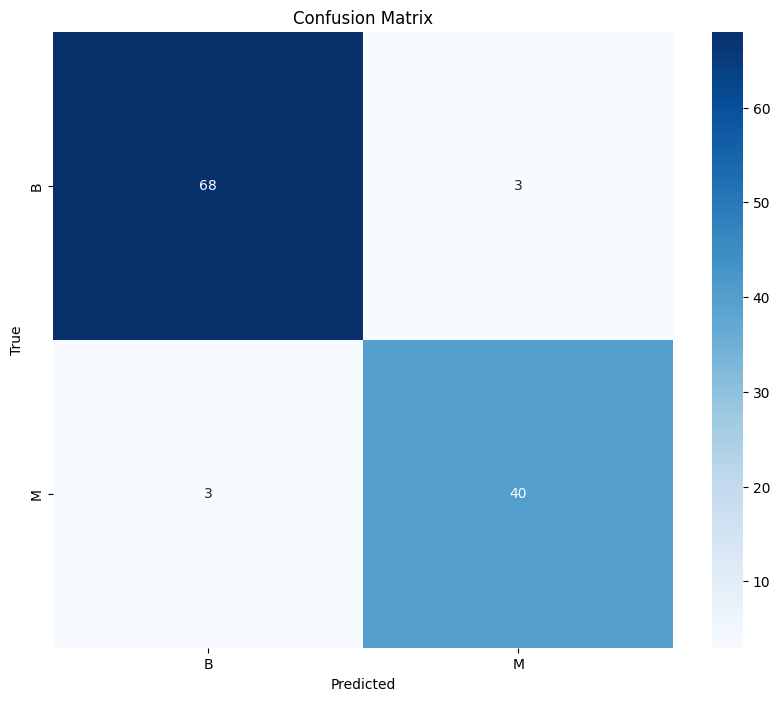

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels
            =['B', 'M'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Visualización de modelo de decisión

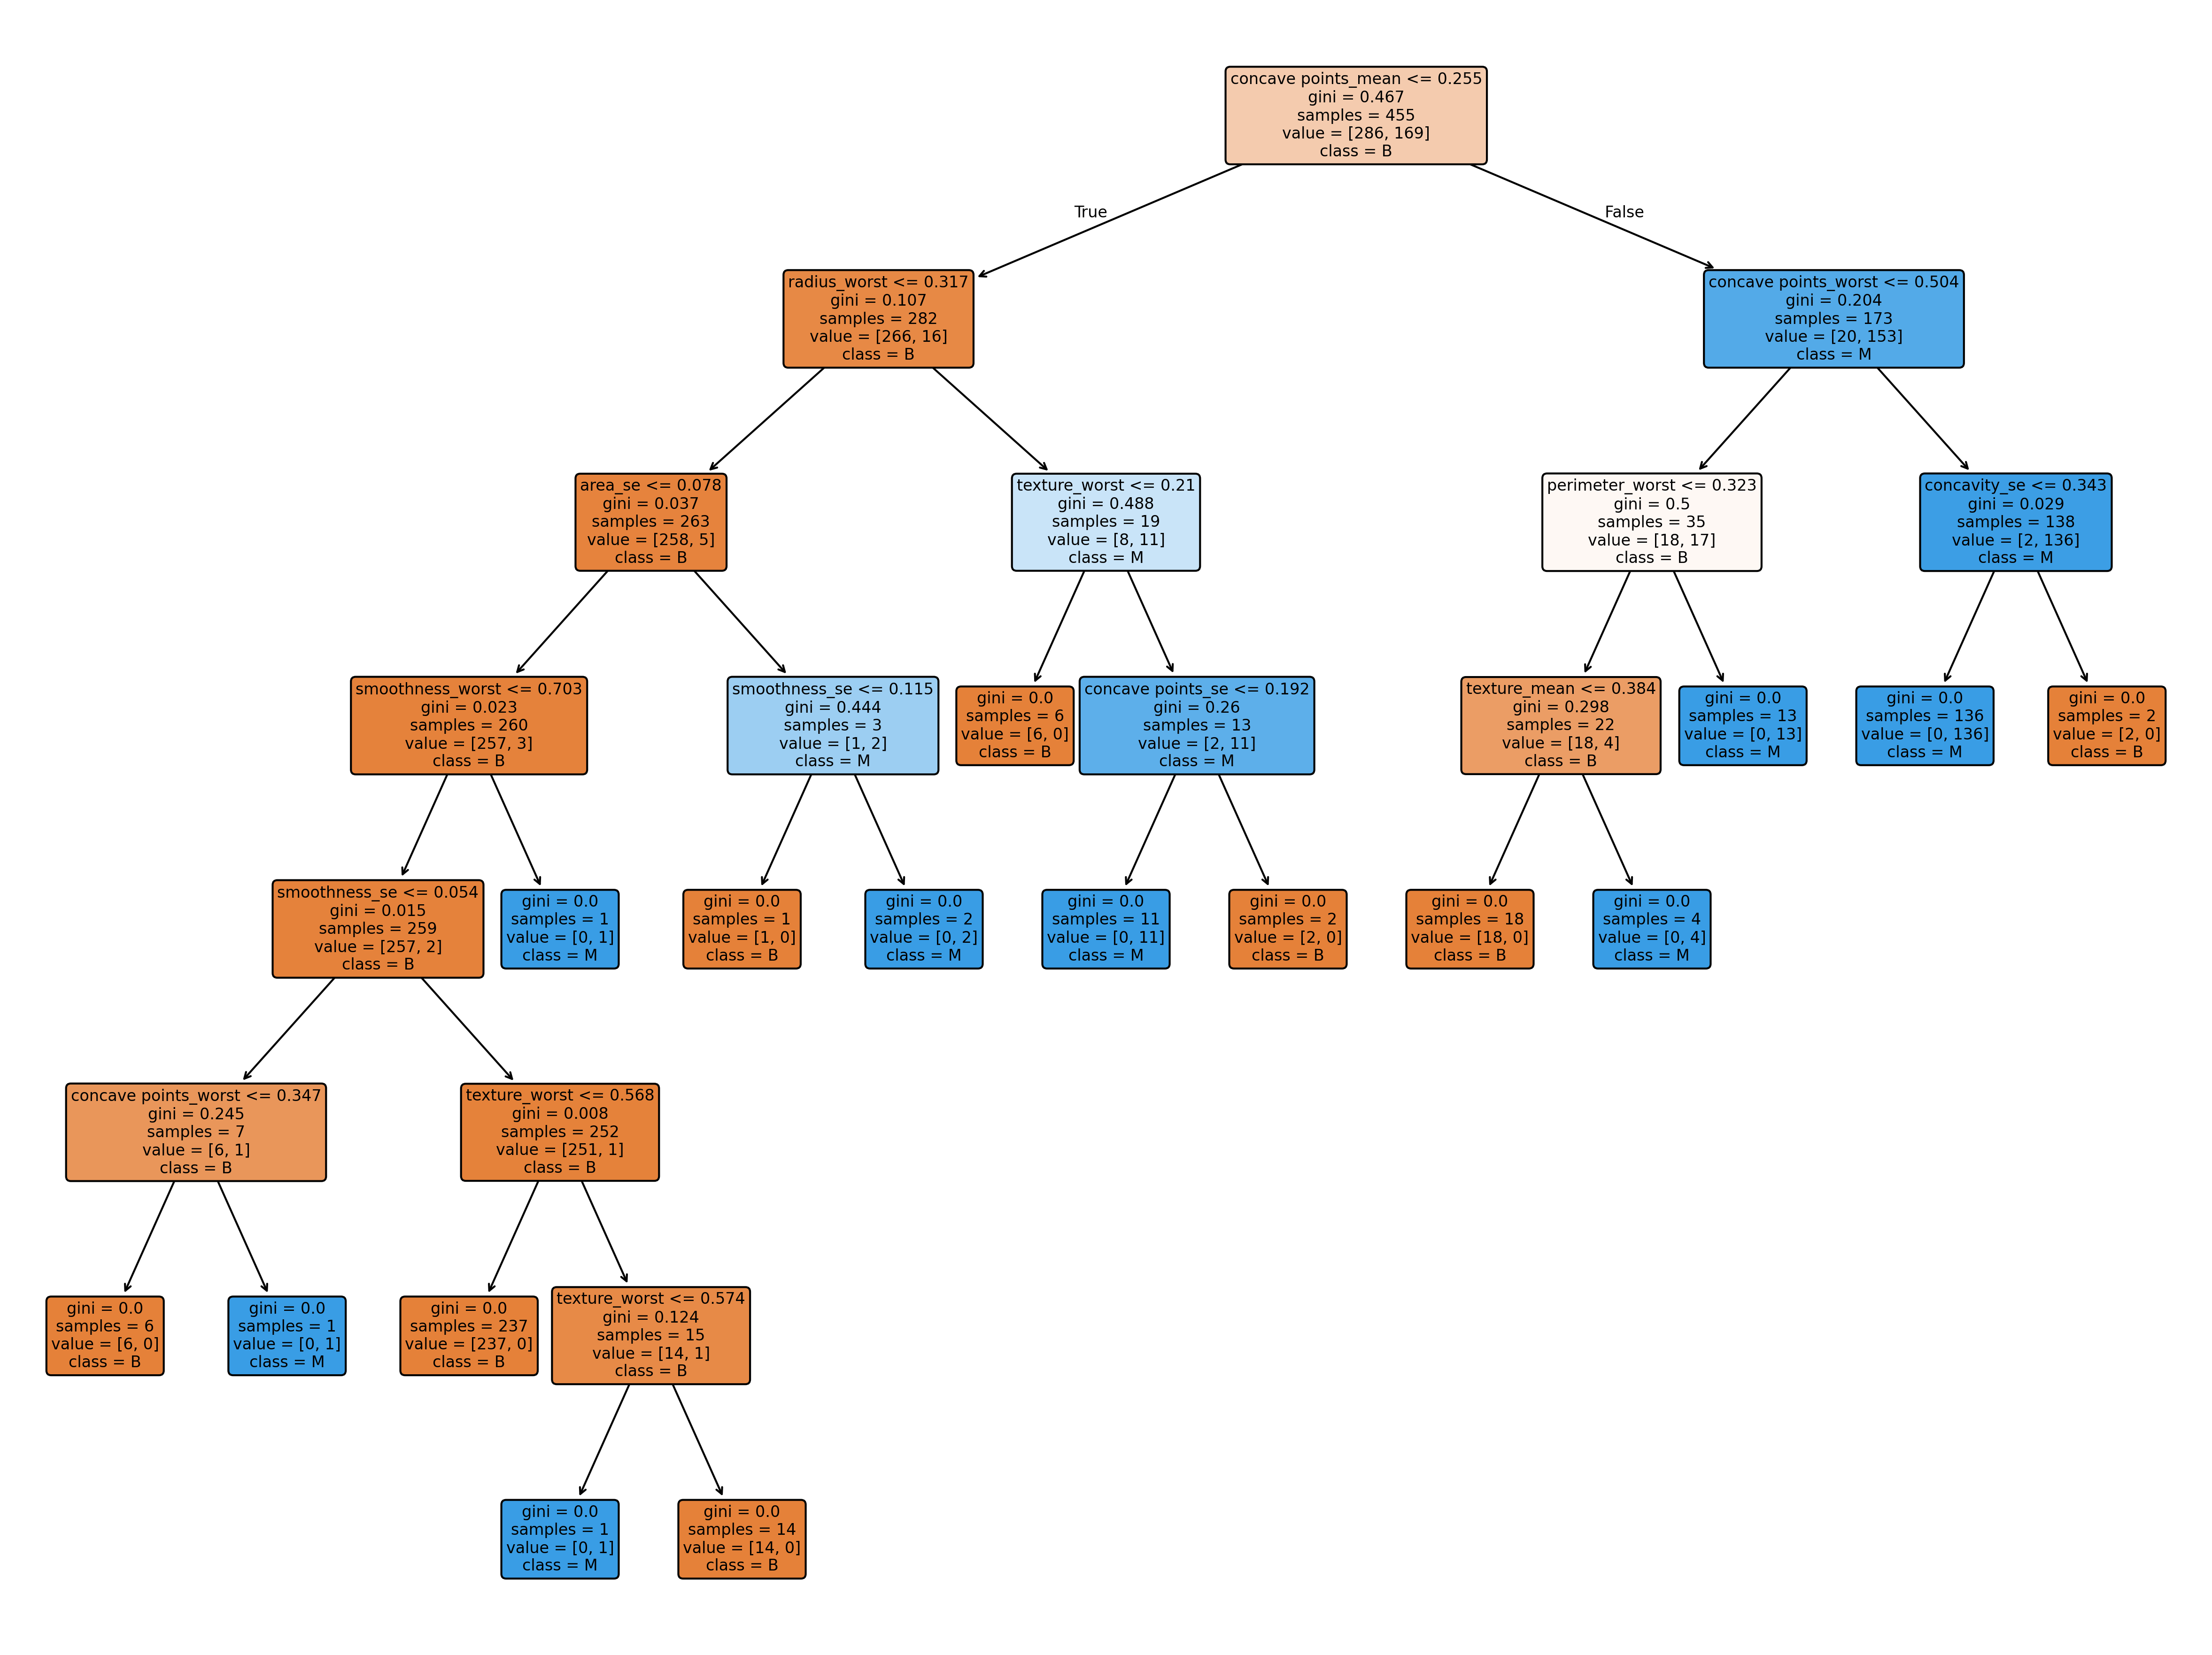

In [ ]:

plt.figure(figsize=(20, 15), dpi=300)

plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=clf.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()